# LMS 코드 실습 및 프로젝트

In [57]:
!pip install opencv-python pixellib

In [58]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print('ready')

ready


원본 고양이 이미지 크기: (536, 536, 3)
배경(사막) 이미지 크기: (549, 893, 3)


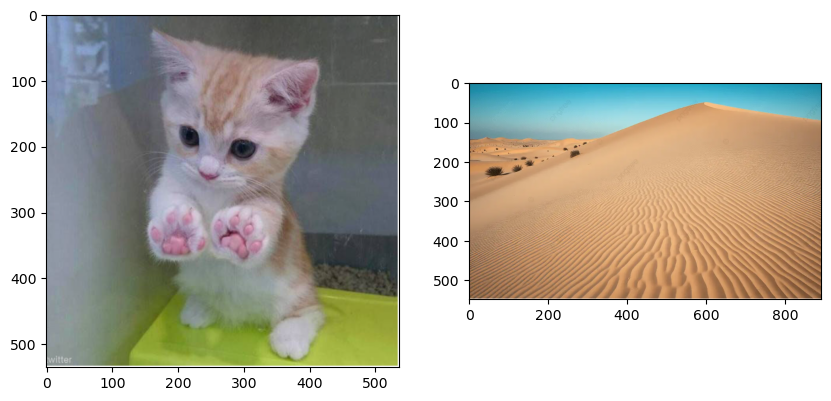

In [59]:
# 고양이 이미지
cat_img_path = "./image/cat.png"  

 # 사막 배경 이미지
sand_img_path = "./image/sand.png"  


cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

# OpenCv 는 BGR 순서로 읽는데 Matplotlib은 RGB 순서라고한다
# 화면 출력 제대로 하려면 RGB 순서로 변환해야한다 
# 왜이렇게 귀찮게 해놨지? 통일 해놓으면 좋을것 같다
cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

# 전체 출력 창 크기
plt.figure(figsize=(10, 5))

# 고양이 위치
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

# 사막 위치
plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [60]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [61]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (536, 536)


In [62]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


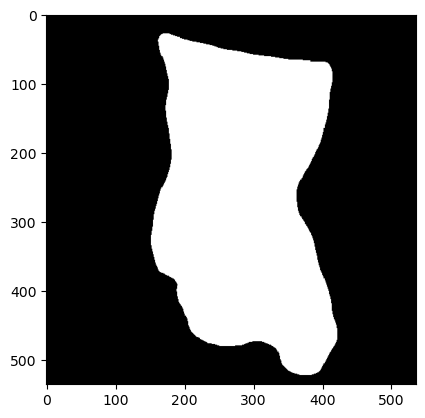

In [63]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

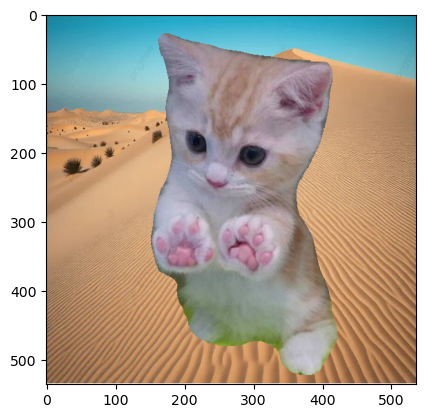

In [64]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

발이 짤렸다!!  

![](./image/cat_delete.png)  

세그먼테이션 작업을 하기에 발 부분이 밝아서 작업이 잘 안된것 같다  

아주 찐한 사진으로 교체한다  


원본 고양이 이미지 크기: (499, 571, 3)
배경(사막) 이미지 크기: (549, 893, 3)


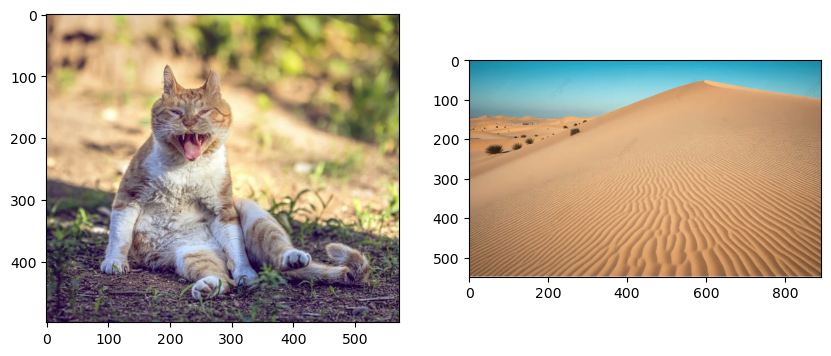

In [65]:
cat_img_path = "./image/cat1.png"  # 고양이 이미지를 준비해주세요
sand_img_path = "./image/sand.png"  # 사막 배경 이미지를 준비해주세요

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [66]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [67]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (499, 571)


In [68]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


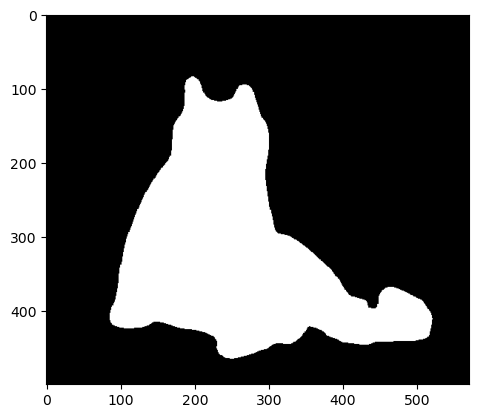

In [69]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

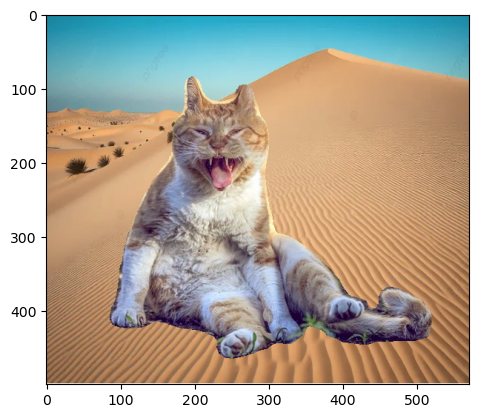

In [70]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

사막에 앉아 있는 앙칼진 고양이다  

![](./image/cat_grass.png)  

다리 사이 풀은 어떻게 하지?  

고양이 주변도 깔끔하게 잘리지 않았다  

AI한테 물어보니 rembg 로 누끼 따고  

opencv로 마스크 찌꺼기 제거  

가장자리 부드럽게 처리  

하면 된단다  

뭐 그래도 이정도면 양호하다 생각하고 다음꺼 진행한다  


In [71]:
!pip install  pillow matplotlib ultralytics

In [72]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

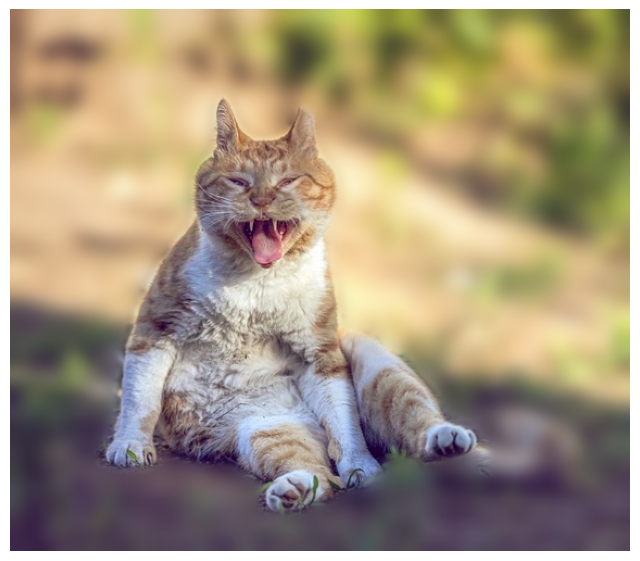

In [73]:
# 고앵이 이미지
INPUT_IMAGE = "./image/cat1.png"

# 아웃포커스 된 이미지
OUTPUT_IMAGE = "./image/cat1_outfocus.png"

# YOLO Segmentation 모델
# 얘가 세그멘테이션을 잘한단다
model = YOLO("yolo11n-seg.pt")

# 이미지 로드
img = cv2.imread(INPUT_IMAGE)

# 맨 위에 언급했듯이 OpenCV 는 BGR 순서로 읽는다
# Matplotlib과 YOLO에서 보기 편하게 귀찮지만 BGR을 RGB로 변환해준다
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

# YOLO로 세그멘테이션한 값 verbose=False는 쓸데없는 출력 메세지 줄인다
result = model(img_rgb, verbose=False)[0]

# 전체 마스크
mask = np.zeros((h, w), dtype=np.uint8)

if result.masks is not None:

    for poly in result.masks.xy:

        pts = np.array(poly, dtype=np.int32)

        cv2.fillPoly(mask, [pts], 255)

# 마스크 경계선 GaussianBlur로 그라데이션
mask = cv2.GaussianBlur(mask, (21, 21), 0)

# mask_f 는 고양이만 딱 가져와서 합성 재료로 만듦
mask_f = mask.astype(np.float32) / 255.0
mask_f = np.dstack([mask_f] * 3)

# 배경 전체를 흐리게
blurred = cv2.GaussianBlur(img_rgb, (51, 51), 0)

# mask_f 고양이 + 블러 배경
out = (
    img_rgb * mask_f +
    blurred * (1.0 - mask_f)
).astype(np.uint8)

# OpenCV로 저장할 때는 RGB를 다시 BGR로 또 바꾼다!!!
cv2.imwrite(
    OUTPUT_IMAGE,
    cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
)

plt.figure(figsize=(8,8))
plt.imshow(out)
plt.axis("off")
plt.show()

아웃포커싱 그렇저렇 되었다  

왜 이렇게 못됏게 생겼지  


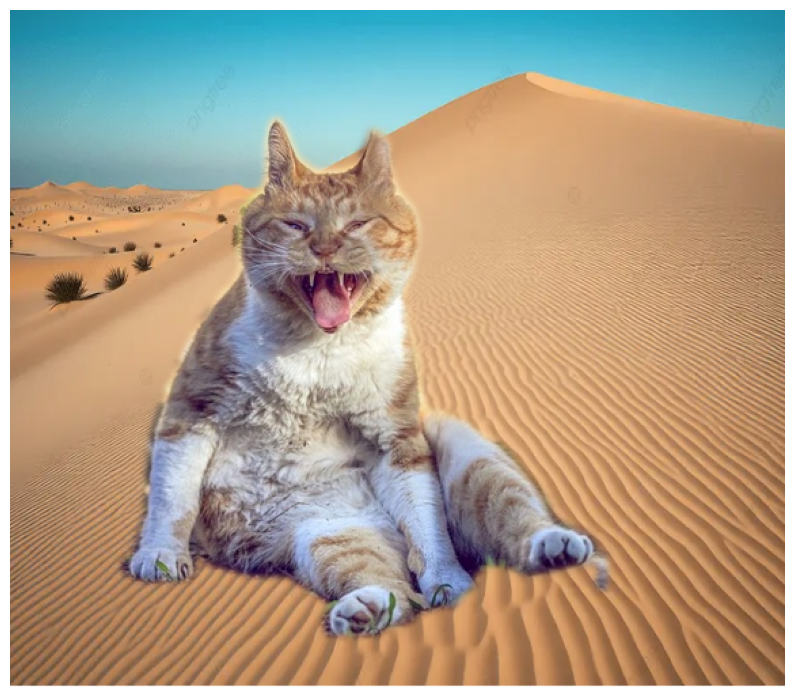

In [74]:
# 고양이 이미지
CAT_IMAGE = "./image/cat1.png"

# 사막배경 이미지
BACKGROUND_IMAGE = "./image/sand.png"

# 고양이 + 사막배경 합성 출력 파일
OUTPUT_IMAGE = "./image/result.png"

# 욜로 모델 로드
model = YOLO("yolo11n-seg.pt")

# 이미지를 읽자
img = cv2.imread(CAT_IMAGE)

# 알지?
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

# 배경도 읽자
bg = cv2.imread(BACKGROUND_IMAGE)

# 알지?
bg = cv2.cvtColor(bg, cv2.COLOR_BGR2RGB)

# 사막 배경을 고양이 사진 크기에 맞춤
bg = cv2.resize(bg, (w, h))

# 고양이 세그멘테이션
result = model(img_rgb, verbose=False)[0]

# 고양이 마스크 만들기
mask = np.zeros((h, w), dtype=np.uint8)

for poly in result.masks.xy:

    points = np.array(poly, dtype=np.int32)

    cv2.fillPoly(mask, [points], 255)

# 고양이 주변 선 그라데이션
mask = cv2.GaussianBlur(mask, (15, 15), 0)

mask_float = mask.astype(np.float32) / 255.0

mask_float = np.dstack([
    mask_float,
    mask_float,
    mask_float
])

# 고양이 + 사막 합성
result_img = (
    img_rgb * mask_float +
    bg * (1.0 - mask_float)
).astype(np.uint8)

# 알지?
cv2.imwrite(
    OUTPUT_IMAGE,
    cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR)
)

plt.figure(figsize=(10, 10))
plt.imshow(result_img)
plt.axis("off")
plt.show()

배경 전환 크로마키도 그렇저렇 된것 같다  

고양이는 역시 하악질 할때가 제일 이쁘다  


# 회고  

세그멘테이션 작업이 꽤나 까다롭다  

원하는 대로 누끼가 따지지 않고 발이 잘리고 이상한 배경도 섞여 들어온다  

좀 더 정밀한 세그멘테이션을 하는 방법을 더 공부해 봐야겠다  
